<a href="https://colab.research.google.com/github/pratheeth123/ML-LAB/blob/main/Week2/Week3_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.metrics import pairwise_distances
from collections import Counter

iris = load_iris()
X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y

input_value = np.array([[3.9, 3.0, 5.1, 1.8]])

distances = pairwise_distances(X, input_value)

df['distance'] = distances

K = 5
top_k = df.sort_values(by='distance').head(K)

print("\nTop 5 Nearest Neighbors:")
print(top_k)

final_class = Counter(top_k['target']).most_common(1)[0][0]

print("\nFinal Predicted Class:", final_class)
print("Class Name:", iris.target_names[final_class])


Top 5 Nearest Neighbors:
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
106                4.9               2.5                4.5               1.7   
84                 5.4               3.0                4.5               1.5   
121                5.6               2.8                4.9               2.0   
66                 5.6               3.0                4.5               1.5   
59                 5.2               2.7                3.9               1.4   

     target  distance  
106       2  1.272792  
84        1  1.643168  
121       2  1.734935  
66        1  1.827567  
59        1  1.838478  

Final Predicted Class: 1
Class Name: versicolor


In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.metrics import pairwise_distances

diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

df = pd.DataFrame(X, columns=diabetes.feature_names)
df['target'] = y

input_value = X[10].reshape(1, -1)

distances = pairwise_distances(X, input_value)

df['distance'] = distances

K = 5
top_k = df.sort_values(by='distance').head(K)

print("\nTop 5 Nearest Neighbors:")
print(top_k)

final_value = top_k['target'].mean()

print("\nFinal Predicted Value:", final_value)


Top 5 Nearest Neighbors:
          age       sex       bmi        bp        s1        s2        s3  \
10  -0.096328 -0.044642 -0.083808  0.008101 -0.103389 -0.090561 -0.013948   
26  -0.107226 -0.044642 -0.077342 -0.026328 -0.089630 -0.096198  0.026550   
126 -0.089063 -0.044642 -0.061174 -0.026328 -0.055231 -0.054549  0.041277   
219 -0.089063 -0.044642 -0.041774 -0.019442 -0.066239 -0.074277  0.008142   
136 -0.092695 -0.044642 -0.081653 -0.057313 -0.060735 -0.068014  0.048640   

           s4        s5        s6  target      distance  
10  -0.076395 -0.062917 -0.034215   101.0  5.268356e-09  
26  -0.076395 -0.042571 -0.005220   137.0  6.679628e-02  
126 -0.076395 -0.093937 -0.054925    99.0  9.903254e-02  
219 -0.039493  0.001148 -0.030072   185.0  1.009688e-01  
136 -0.076395 -0.066490 -0.021788    85.0  1.034845e-01  

Final Predicted Value: 121.4


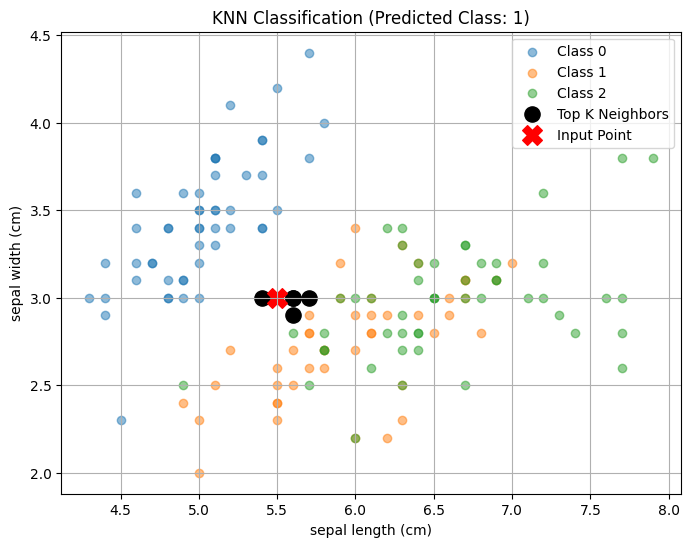

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.metrics import pairwise_distances
from collections import Counter


iris = load_iris()
X = iris.data[:, :2]
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names[:2])
df['target'] = y


input_value = np.array([[5.5, 3.0]])

distances = pairwise_distances(X, input_value)
df['distance'] = distances

K = 5
top_k = df.sort_values(by='distance').head(K)

final_class = Counter(top_k['target']).most_common(1)[0][0]

plt.figure(figsize=(8,6))

plt.scatter(df[df['target']==0].iloc[:,0],
            df[df['target']==0].iloc[:,1],
            label='Class 0', alpha=0.5)

plt.scatter(df[df['target']==1].iloc[:,0],
            df[df['target']==1].iloc[:,1],
            label='Class 1', alpha=0.5)

plt.scatter(df[df['target']==2].iloc[:,0],
            df[df['target']==2].iloc[:,1],
            label='Class 2', alpha=0.5)

plt.scatter(top_k.iloc[:,0], top_k.iloc[:,1],
            color='black', s=120, label='Top K Neighbors')

plt.scatter(input_value[0][0], input_value[0][1],
            color='red', marker='X', s=200, label='Input Point')

plt.title(f"KNN Classification (Predicted Class: {final_class})")
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.legend()
plt.grid(True)
plt.show()

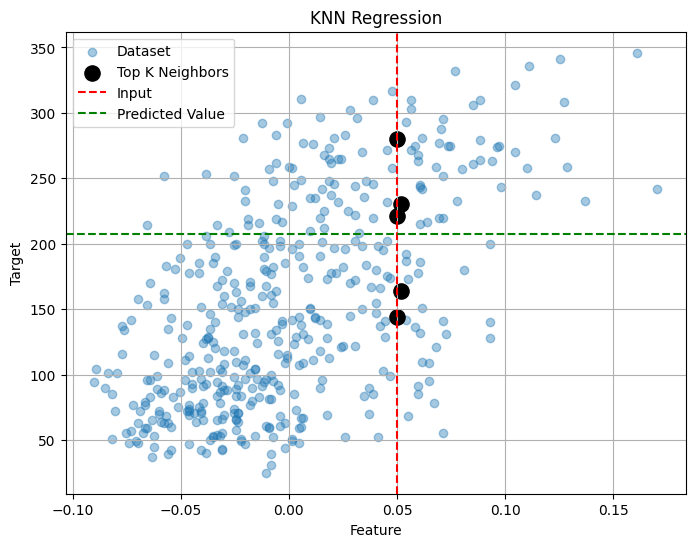

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.metrics import pairwise_distances


diabetes = load_diabetes()
X = diabetes.data[:, 2].reshape(-1,1)
y = diabetes.target

df = pd.DataFrame(X, columns=['feature'])
df['target'] = y


input_value = np.array([[0.05]])


distances = pairwise_distances(X, input_value)
df['distance'] = distances

K = 5
top_k = df.sort_values(by='distance').head(K)

final_value = top_k['target'].mean()

plt.figure(figsize=(8,6))

plt.scatter(df['feature'], df['target'], alpha=0.4, label='Dataset')

plt.scatter(top_k['feature'], top_k['target'],
            color='black', s=120, label='Top K Neighbors')


plt.axvline(x=input_value[0][0], color='red', linestyle='--', label='Input')

plt.axhline(y=final_value, color='green', linestyle='--', label='Predicted Value')

plt.title("KNN Regression")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.legend()
plt.grid(True)
plt.show()